In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score

In [2]:
X = 6 * np.random.rand(200, 1) - 3
y = 0.8 * X ** 2 + 0.9 * X + 2 + np.random.rand(200,1)

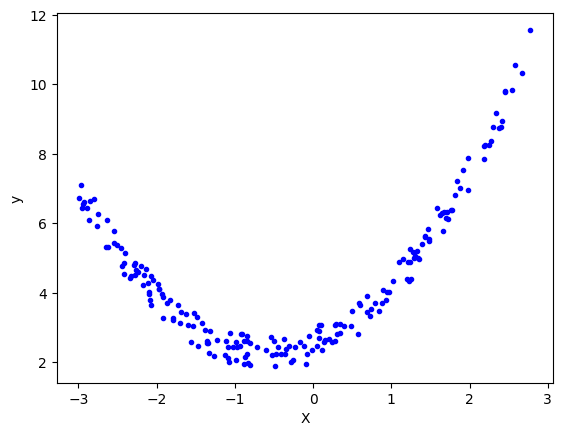

In [3]:
plt.plot(X, y, 'b.')
plt.xlabel("X")
plt.ylabel("y")
plt.show()

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

### Linear Regtression Algorithm

In [5]:
lr = LinearRegression()
lr.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [6]:
y_pred = lr.predict(X_test)
print("R2 Score", r2_score(y_test, y_pred))

R2 Score -0.37483672400395385


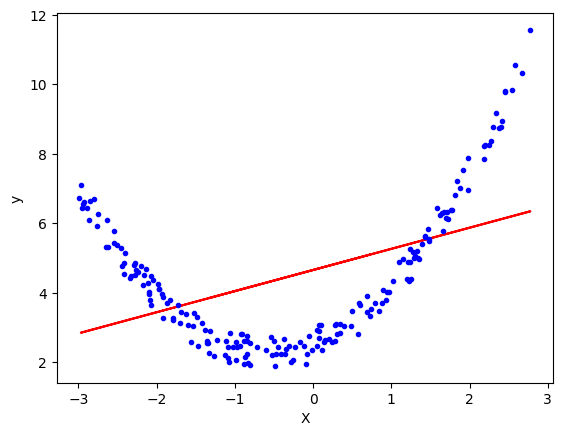

In [7]:
plt.plot(X_train, lr.predict(X_train), color='r')
plt.plot(X, y, 'b.')
plt.xlabel("X")
plt.ylabel("y")
plt.show()

### POlynomial Regression

In [8]:
poly = PolynomialFeatures(degree=2)   # include_bias = True

X_train_trans = poly.fit_transform(X_train)
X_test_trans = poly.transform(X_test)

In [9]:
print(X_train[0])
print(X_train_trans[0])

[0.72633148]
[1.         0.72633148 0.52755742]


In [10]:
lr = LinearRegression()
lr.fit(X_train_trans, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [11]:
y_pred = lr.predict(X_test_trans)
print("R2 Score", r2_score(y_test, y_pred))

R2 Score 0.9629036822637027


In [12]:
print(lr.coef_)
print(lr.intercept_)

[[0.         0.88448799 0.79208257]]
[2.53562879]


In [13]:
X_new = np.linspace(-3, 3, 200).reshape(200, 1)
X_new_poly = poly.transform(X_new)
y_new = lr.predict(X_new_poly)

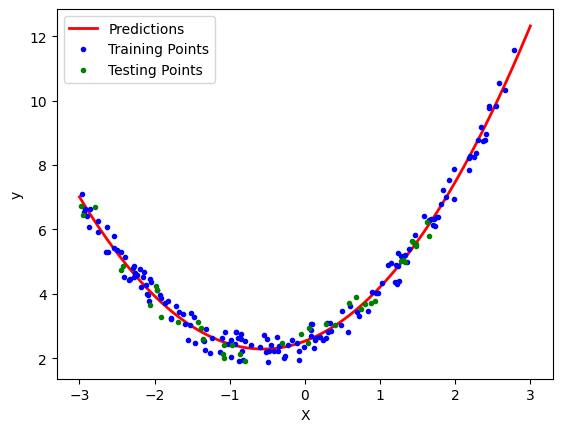

In [14]:
plt.plot(X_new, y_new, "r-", linewidth='2', label='Predictions')
plt.plot(X_train, y_train, "b.", label='Training Points')
plt.plot(X_test, y_test, "g.", label='Testing Points')
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()